# Group Report - Predicting Following Day Rainfall in Australia


## 1.0 Introduction

#### 1.1 Background

Humans have been looking to the sky for thousands of years in hopes of forecasting the elements. Yet, only after the 1850s, did humanity begin systematically collecting meteorological data to scientifically predict weather conditions[1]. From the rain's immense impact on various industries, societal infrastructure, and general day-to-day life, predicting its occurrence is pivotal to many facets of society[2]. Particularly, The Australian Bureau of Meteorology has amassed over 10 years of weather data with consistent daily measurements of variables such as wind, humidity, temperature, and most importantly, rain.

#### 1.2 Central Question

Using the data collected in Australia and a classification approach, the research question of our project is:  
**"Will it rain tomorrow in Australia based on a set of meteorological characteristics from the previous day?"**

#### 1.3 Dataset

The dataset that we will use is the “Rain in Australia” dataset by Joe Young and Adam Young. This dataset contains meteorological data across 10 years in Australia from 2007/10/31 to 2017/6/24 in various regions, collected by weather stations across Australia. The dataset contains variables such as weather conditions - wind speed, wind direction and temperature, as well the amount of precipitation in the form of rain on any given day.

## 2.0 Methods & EDA


#### 2.1 Wrangling

To aid in our decision for predictor variables, we can visualize which columns are present with the most valid data (least NA columns). A larger sample of data would allow us to reduce the impact of factors such as random error in the observation process and improve the overall quality of the analysis. However, due to computational limits, we will need to address our sample size during our analysis.

In [47]:
#load tidyverse and necessary packages!
library(tidyverse)
library(tidymodels)
library(modeldata)
install.packages("themis")
library(themis)
library(knitr)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [31]:
#load data into r and set the seed for the rest of the analysis. This will standardize our analysis for reproducibility.
set.seed(9784)

url <- "https://raw.githubusercontent.com/Andrewyx/DSCI100-Project-G16/main/weatherAUS.csv"
weather_data_raw <- read_csv(url)

Rows: 145460 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): Location, WindGustDir, WindDir9am, WindDir3pm, RainToday, RainTom...
dbl  (16): MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed,...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [58]:
# Summarize each row by counting non-N/A cells. Renames the variables afterwards after conversion to a data frame
# This lets us see the variables containing the most amount of usable data, and thus choose our predictors!

no_na_data <- as.data.frame((colSums(!is.na(weather_data_raw)))) 
no_na_data <- cbind(rownames(no_na_data), no_na_data)
rownames(no_na_data) <- NULL
colnames(no_na_data) <- c("measurement","count")

count_tbl <- arrange(no_na_data, desc(count))
cat("Table 1: Summary of non-N/A Cells For Each Predictor")
count_tbl

Table 1: Summary of non-N/A Cells For Each Predictor

measurement,count
<chr>,<dbl>
Date,145460
Location,145460
MaxTemp,144199
MinTemp,143975
WindSpeed9am,143693
Temp9am,143693
Humidity9am,142806
WindSpeed3pm,142398
Rainfall,142199


In [33]:
#Remove categorical variables & variables with too many N/A values (Wrangle Data).
#Also remove redundant variables (MaxTemp & MinTemp) which increases the complexity of the model (Since we have Temp3pm & Temp9am).  

weather_data_clean <- weather_data_raw |>
                            select(-WindGustDir, -WindDir9am, -WindDir3pm, -RainToday, -Date, -Location) |>
                            select(-Sunshine, -Evaporation, -Cloud3pm, -Cloud9am) |>
                            select(-MaxTemp, -MinTemp) |>
                            transform(RainTomorrow = as.factor(RainTomorrow))

In [34]:
# Split training and testing sets
weather_data_reduced <- sample_n(weather_data_clean, 8000)
weather_split <- initial_split(weather_data_reduced, prop = 0.75, strata = RainTomorrow)
weather_train <- training(weather_split)
weather_test <- testing(weather_split)

#### 2.2 Summarizing Training Data
We now create two summary tables of the training data.

In [35]:
glimpse(weather_train)

Rows: 5,999
Columns: 11
$ Rainfall      <dbl> 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0…
$ WindGustSpeed <dbl> 39, 35, 26, NA, 50, 69, NA, NA, 44, 33, NA, 30, 43, 24, …
$ WindSpeed9am  <dbl> 17, 11, 9, 0, 13, 20, NA, 4, 19, 15, 0, 6, 26, 6, 15, 6,…
$ WindSpeed3pm  <dbl> 30, 15, 11, 4, 30, 30, NA, 4, 24, 9, 9, 19, 24, 17, 17, …
$ Humidity9am   <dbl> 60, 72, 81, 69, 78, 37, 77, 97, 66, 93, 85, 84, 49, 64, …
$ Humidity3pm   <dbl> 49, 50, 57, 63, 33, 28, 21, 61, 27, 74, 52, 57, 43, 72, …
$ Pressure9am   <dbl> 1011.7, 1025.9, 1029.4, NA, 1017.6, NA, NA, NA, 1025.3, …
$ Pressure3pm   <dbl> 1008.4, 1023.4, 1025.7, NA, 1014.5, NA, NA, NA, 1020.3, …
$ Temp9am       <dbl> 28.4, 9.3, 7.8, 21.8, 13.3, 16.3, 15.6, 13.8, 9.3, 11.6,…
$ Temp3pm       <dbl> 31.3, 14.4, 10.9, 24.7, 26.7, 23.1, 24.0, 20.0, 18.8, 14…
$ RainTomorrow  <fct> No, No, No, No, No, No, No, No, No, No, No, No, No, No, …


#### Means and Missing Rows
The first two summary tables present the means of the predictor variables and the number of rows with missing data.

In [36]:
# Summary table of the mean of predictor variables and rows with missing data

summary_weather_train <- weather_train|>
  summarize(
    Mean_Rainfall = mean(Rainfall, na.rm = TRUE),
    Mean_WindGustSpeed = mean(WindGustSpeed, na.rm = TRUE),
    Mean_WindSpeed9am = mean(WindSpeed9am, na.rm = TRUE),
    Mean_WindSpeed3pm = mean(WindSpeed3pm, na.rm = TRUE),
    Mean_Humidity9am = mean(Humidity9am, na.rm = TRUE),
    Mean_Humidity3pm = mean(Humidity3pm, na.rm = TRUE),
    Mean_Pressure9am = mean(Pressure9am, na.rm = TRUE),
    Mean_Pressure3pm = mean(Pressure3pm, na.rm = TRUE),
    Mean_Temp9am = mean(Temp9am, na.rm = TRUE),
    Mean_Temp3pm = mean(Temp3pm, na.rm = TRUE))|>
    as.data.frame() |>
    pivot_longer(cols=everything(), names_to="Mean_Categories", values_to="Means")
summary_weather_train

missing_data_table <- tibble(Rows_with_Missing_Data = sum(rowSums(is.na(weather_train)) > 0))
missing_data_table

Mean_Categories,Means
<chr>,<dbl>
Mean_Rainfall,2.294905
Mean_WindGustSpeed,39.957012
Mean_WindSpeed9am,13.947502
Mean_WindSpeed3pm,18.600546
Mean_Humidity9am,68.957378
Mean_Humidity3pm,51.976728
Mean_Pressure9am,1017.620753
Mean_Pressure3pm,1015.252638
Mean_Temp9am,17.032169


Rows_with_Missing_Data
<int>
1075


#### Available Target Variable Data
The second summary table shows the counts of observations in our target RainTomorrow class. We observe here that the data appears to be heavily unbalanced.

In [37]:
# Summary table for counts of RainTomorrow observation 

summary_num_obs<-weather_train|>
  group_by(RainTomorrow)|>
  summarize(count=n())
summary_num_obs

RainTomorrow,count
<fct>,<int>
No,4555
Yes,1311
NA,133


#### 2.3 Visualizing training data

Now we compare the distributions of each of the predictor variables.

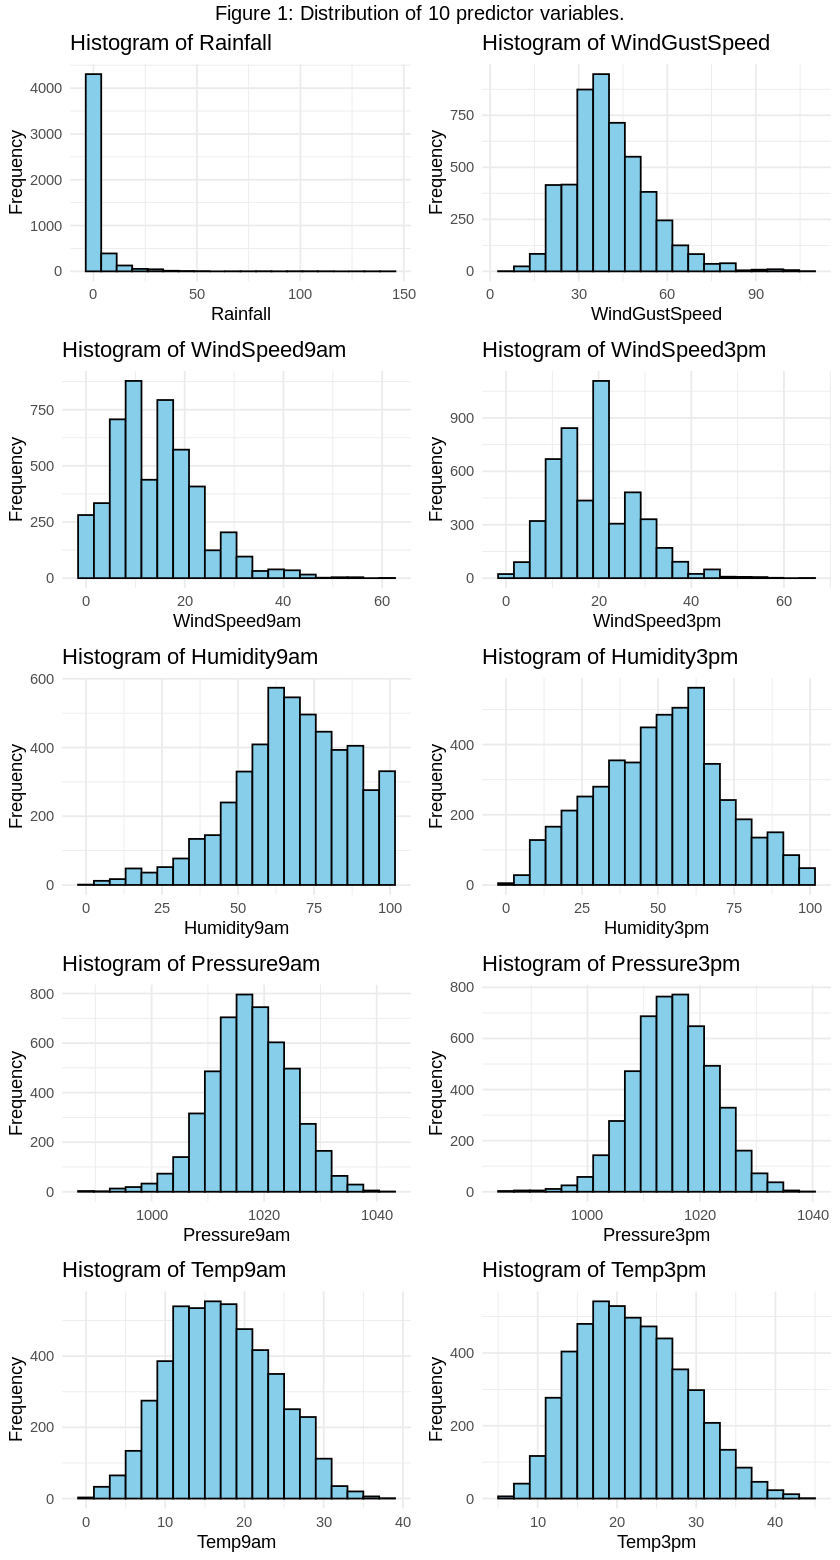

In [38]:
# Visualize distributions of variables via histogram

options(repr.plot.height = 13, repr.plot.width = 7)
library(ggplot2)
library(gridExtra)

weather_predictors <- na.omit(select_if(weather_train, is.numeric))
plots<-lapply(names(weather_predictors), function(col)  {
    ggplot(weather_predictors, aes(x = .data[[col]])) +
      geom_histogram(fill = "skyblue", color = "black",bins=20) +
      labs(title = paste("Histogram of", col),
           x = col, y = "Frequency" ) +
      theme_minimal()
  })
grid.arrange(grobs = plots, ncol = 2, top = "Figure 1: Distribution of 10 predictor variables.")



## 3.0 Data Analysis & Results

First, we must remove the previously found NA rows from our training and testing data.

In [39]:
# Omit the NA rows from the training and testing data
weather_train_clean <- weather_train |>
                            na.omit()

weather_test_clean <- weather_test |>
                            na.omit()

#### 3.1 Tuning the Model for K

Since we are using knn classification to conduct our data analysis, we must find a suitable K for our model. Through the EDA we observed that the data was heavily unbalanced, hence we will use downsampling to balance the data. Downsampling is chosen in this case due to the large dataset and the computational limitations of this project. We will also need to scale and center our data to ensure consistency across Euclidean distances.

In [40]:
# Finding K with tuning and including downsampling in our recipe. We make our recipe with all predictors of our weather_train_clean data set.
knn_spec_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
                         set_engine("kknn") |>
                         set_mode("classification")

rain_recipe <- recipe(RainTomorrow ~ ., data=weather_train_clean)|>
                        step_downsample(under_ratio = 1, RainTomorrow) |>
                        step_scale(all_predictors()) |>
                        step_center(all_predictors())
                        
rain_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:    1
predictor: 10



── Operations 

• Down-sampling based on: RainTomorrow

• Scaling for: all_predictors()

• Centering for: all_predictors()



#### 3.2 Cross Validation

We can now test a range of K's with cross-validation to find the best-suited K for our model. For this, we have chosen a range of K's from 1 to 70  incrementing by K's of 5. K values beyond the range of 70 would be too computationally costly to justify the diminishing returns to accuracy (See graph of K).

In [41]:
# Cross-validation and finding K for tests of values from 1 to 70
k_vals <- tibble(neighbors = seq(from = 1, to = 70, by = 5))
rain_vfold <- vfold_cv(weather_train_clean, v = 5, strata = RainTomorrow)

# Create a workflow and collect the metrics from our validations.
knn_results <- workflow() |>
  add_recipe(rain_recipe) |>
  add_model(knn_spec_tune) |>
  tune_grid(resamples = rain_vfold, grid = k_vals)|>
  collect_metrics()

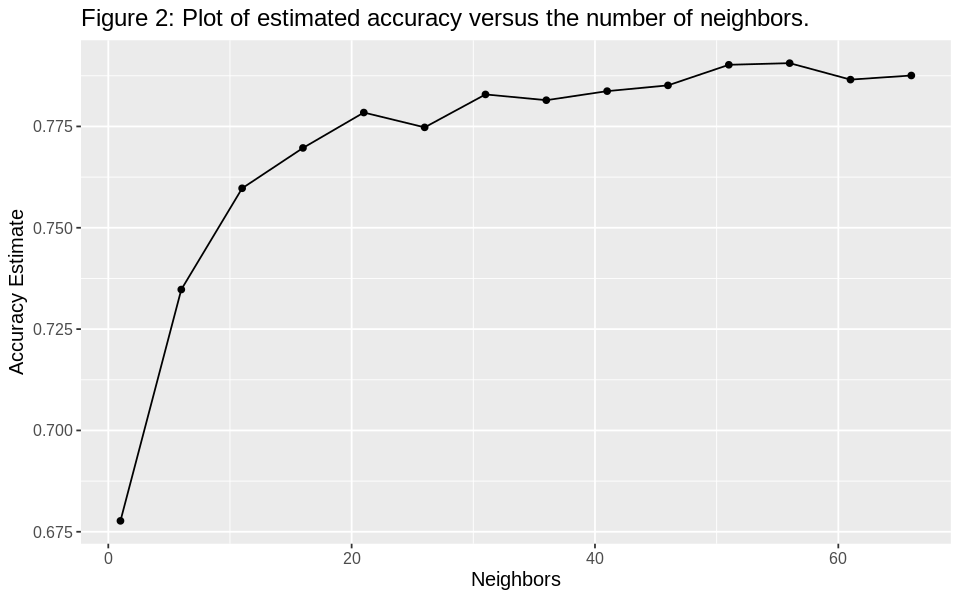

In [42]:
options(repr.plot.width = 8, repr.plot.height = 5)

# Store all mean accuracy measurements and plot against their corresponding K values.
accuracies <- knn_results |>
  filter(.metric == "accuracy")

accuracy_vs_k <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
  geom_point() +
  geom_line() +
  labs(title="Figure 2: Plot of estimated accuracy versus the number of neighbors.", x= "Neighbors", y = "Accuracy Estimate") +
  theme(text = element_text(size = 12))
accuracy_vs_k

#### 3.3 Best K Value
Our best K value can now be pulled from our accuracy data frame. Since we see from the above graph that accuracy plateaus with increasing K, this implies diminishing returns for increasing K. For us, the best K within our range appears to be 56. From this, we observe that our model for k=56 appears to have an accuracy of 79.1%.

In [43]:
# Pull the highest k based on mean accuracy as our desired K value
accuracies |>
    arrange(desc(mean)) |>
    head(1)

best_k <- accuracies |>
        arrange(desc(mean)) |>
        head(1) |>
        pull(neighbors)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
56,accuracy,binary,0.7906092,5,0.007615814,Preprocessor1_Model12


#### 3.4 Final KNN Model
We can now build our classification model with the ideal K from above, fitting it with our clean training data.

In [44]:
# Build the final knn model with our chosen k value from the table above.
knn_spec_final <- nearest_neighbor(weight_func = "rectangular", neighbors = best_k) |>
     set_engine("kknn") |>
     set_mode("classification")

knn_fit <- workflow() |>
  add_recipe(rain_recipe) |>
  add_model(knn_spec_final) |>
  fit(data=weather_train_clean)
knn_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
3 Recipe Steps

• step_downsample()
• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(56,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2427366
Best kernel: rectangular
Best k: 56

#### 3.5 Results
Predicting RainTomorrow on our testing data nets us a final accuracy, precision, and recall value. Our final accuracy lies around 80.1%. These results are shown below alongside precision (52.7%) and recall (75.6%).

In [45]:
# Testing and Evaluating the model

rain_test_predictions <- predict(knn_fit, weather_test_clean) |>
  bind_cols(weather_test_clean) 

rain_test_predictions |>
  metrics(truth = RainTomorrow, estimate = .pred_class) |>
  filter(.metric == "accuracy")

rain_test_predictions |>
    precision(truth = RainTomorrow, estimate = .pred_class, event_level="second")

rain_test_predictions |>
    recall(truth = RainTomorrow, estimate = .pred_class, event_level="second")

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.8011976


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.5271318


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.7555556


#### 3.6 Analysis Visualization
To better visualize our results, we can use a confusion matrix in the form of a heatmap to compare our Truth and Prediction values.

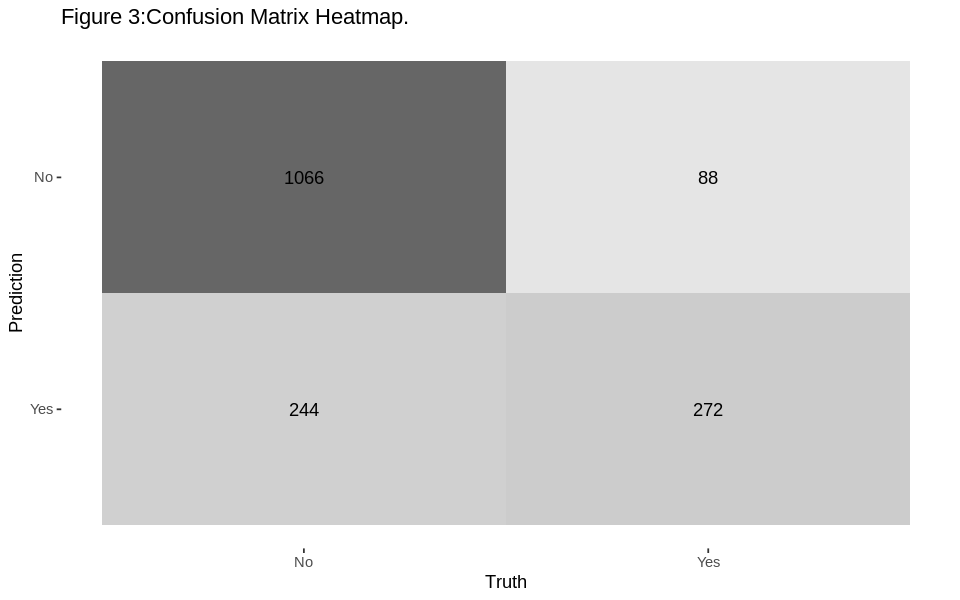

In [46]:
# Visualize with Confusion Matrix
confusion <- rain_test_predictions |>
             conf_mat(truth = RainTomorrow, estimate = .pred_class)
confusion_plot<-autoplot(confusion, type = "heatmap")+
   ggtitle("Figure 3:Confusion Matrix Heatmap.")
confusion_plot

## 4.0 Discussion

#### 4.1 Outcome

Using the K-nearest neighbors algorithm, we've developed a classifier to predict there will be rainy the next day in Australia, based on a specific set of weather characteristics as input. This model achieves an accuracy of 80.1%, indicating the proportion of overall correct predictions. Additionally, it gives a precision of 52.7%, highlighting the proportion of correctly predicted rainy days among all predicted rainy days. Furthermore, the recall is 75.6%, indicating the proportion of correctly predicted rainy days among all actual rainy days. These metrics provide a comprehensive evaluation of our classifier's performance. In terms of our expectations, we aimed for our classification model to be able to predict results based on learning correlations within the data and without simply memorizing data points. Achieving an 80.1% accuracy aligns fairly well with our anticipated outcomes. This accuracy rate suggests that our model's predictions closely align with the actual labels assigned to the observations in the test set.

#### 4.2 Limitation


The classifier is likely unacceptable with a precision of 52.7%. However, precision quantifies how many of the positive predictions the classifier made were actually positive. In this context, it indicates the classifier's tendency to forecast rain when it does not occur. However, it's essential to recognize the inherent trade-off between precision and recall. Models with high precision tend to have low recall and vice versa. In this example, accurately predicting an actual rainy day seems to be more important. Incorrectly predicting a rainy day might prompt people to prepare for inclement weather, but it would be far better than fair to anticipate an actual rainfall which brings unforeseen accidents or disruptions. Therefore, prioritizing the correct prediction of rainy days is paramount, even if it means accepting a lower precision rate.

#### 4.3 Significance

The significance of this analysis lies in the immense impact that weather and in particular, rain, has on society. Being able to predict rain is not only beneficial for day-to-day life but quintessential for industries such as agriculture, tourism, and urban development[2].

#### 3.3 Extended/Further Questions

Investigating precipitation further in the future can prompt inquiries on how rain patterns have evolved throughout the last decade. Furthermore, this investigation can also prompt further analysis into how accurate our model can be when compared to modern circumstances (ie, how can we better tune our model for precision or recall instead?).

## 5.0 References

[1] Pfister, C., White, S., & Mauelshagen, F. (2018). General Introduction: Weather, Climate, and Human History. https://doi.org/10.1057/978-1-137-43020-5_1
Bell, W. T., & Ogilvie, A. E. J. (1978). Weather compilations as a source of data for the reconstruction of European climate during the Medieval period. Climatic Change, 1(4), 331-348. https://doi.org/10.1007/BF00135154

[2] P. Agbo, E. (2021). The Role of Statistical Methods and Tools for Weather Forecasting and Modeling. IntechOpen. doi: 10.5772/intechopen.96854